Imports

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from pathlib import Path

%matplotlib inline

Configuration

In [ ]:
MODELS = ["azure-deepseek-r1", "gpt-4o", "gpt3-5", "azure-llama3.3-70b"]
CONDITIONS = ["ctx_none", "ctx_autism", "ctx_neuro", "ctx_all", "ctx_autistic_s1", "ctx_autistic_s2"]

CONDITION_LABELS = {
    "ctx_none":         "No Context",
    "ctx_autism":       "Autism Context",
    "ctx_neuro":        "Neuro-informed",
    "ctx_all":          "All Context",
    "ctx_autistic_s1":  "S1 Autistic",
    "ctx_autistic_s2":  "S2 Autistic",
}

def get_model_label(model: str) -> str:
    return {
        "gpt3-5":             "GPT-3.5",
        "gpt-4o":             "GPT-4o",
        "azure-llama3.3-70b": "LLaMA 3.3",
        "azure-deepseek-r1":  "DeepSeek",
    }.get(model, model)

BAR_WIDTH = 0.17
SPEAKERS = ["Speaker 1", "Speaker 2"]
SPEAKER_STYLES = {
    "Speaker 1": {"color": "#CC79A7", "hatch": "...."},  # mauve
    "Speaker 2": {"color": "#56B4E9", "hatch": "////"},  # sky blue
}

GRAPH_DEFINITIONS = [
    ("figurative_analysis", "transparent", "Figurative - Transparent"),
    ("figurative_analysis", "semi-transparent", "Figurative - Semi-Transparent"),
    ("blunt_analysis", "self", "Blunt - Self"),
    ("blunt_analysis", "non-self", "Blunt - Non-Self"),
    ("indirect_analysis", "knowledge", "Indirect - Knowledge"),
    ("indirect_analysis", "existential", "Indirect - Existential"),
    ("indirect_analysis", "permission", "Indirect - Permission"),
    ("indirect_analysis", "verification", "Indirect - Verification"),
]

Plot

In [ ]:
def plot_exact_ratings(path: Path, title_text):
    df = pd.read_csv(path)
    df = df[df["status"] == "completed"].copy()
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    
    n_models   = len(MODELS)
    n_conds    = len(CONDITIONS)
    pair_width = len(SPEAKERS) * BAR_WIDTH
    model_gap  = 0.06
    group_gap  = 0.25
    group_width = n_models * (pair_width + model_gap) + group_gap
    group_centers = np.arange(n_conds) * group_width

    fig, ax = plt.subplots(figsize=(18, 7))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for m_idx, model in enumerate(MODELS):
        pair_center_offset = (m_idx - (n_models - 1) / 2) * (pair_width + model_gap)
        pair_centers = group_centers + pair_center_offset
        
        for s_idx, speaker in enumerate(SPEAKERS):
            style = SPEAKER_STYLES[speaker]
            bar_offset = (s_idx - 0.5) * BAR_WIDTH
            x_positions = pair_centers + bar_offset
            
            heights = []
            for cond in CONDITIONS:
                val = df[(df["speaker"]==speaker) & (df["model"]==model) & (df["condition"]==cond)]["rating"].mean()
                heights.append(val if not np.isnan(val) else 0.0)
            
            ax.bar(x_positions, heights, width=BAR_WIDTH, 
                   color=style["color"], hatch=style["hatch"], 
                   edgecolor="black", linewidth=0.4, zorder=2)

        for gc in group_centers:
            ax.text(gc + pair_center_offset, -0.28, get_model_label(model), 
                    ha="center", va="top", fontsize=7, rotation=35, color="#333333")

    for i in range(1, len(CONDITIONS)):
        ax.axvline((group_centers[i-1] + group_centers[i])/2, color="#bbbbbb", lw=0.8, ls="--", zorder=1)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS], fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", which="both", length=0, pad=45)
    
    ax.set_ylim(0, 6.0)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(["1\n(No improvement)", "2", "3", "4", "5\n(Significant improvement)"], fontsize=9)
    ax.set_ylabel("Average Likert-Scale Rating (1–5)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.set_title(f"{title_text} — Likert-Scale Ratings", fontsize=13, fontweight="bold", pad=14)

    legend_patches = [mpatches.Patch(facecolor=SPEAKER_STYLES[s]["color"], hatch=SPEAKER_STYLES[s]["hatch"], 
                                     edgecolor="black", label=s) for s in SPEAKERS]
    ax.legend(handles=legend_patches, title="Speaker", title_fontsize=9, fontsize=9, 
              loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, edgecolor="#cccccc")

    plt.tight_layout()
    plt.show()

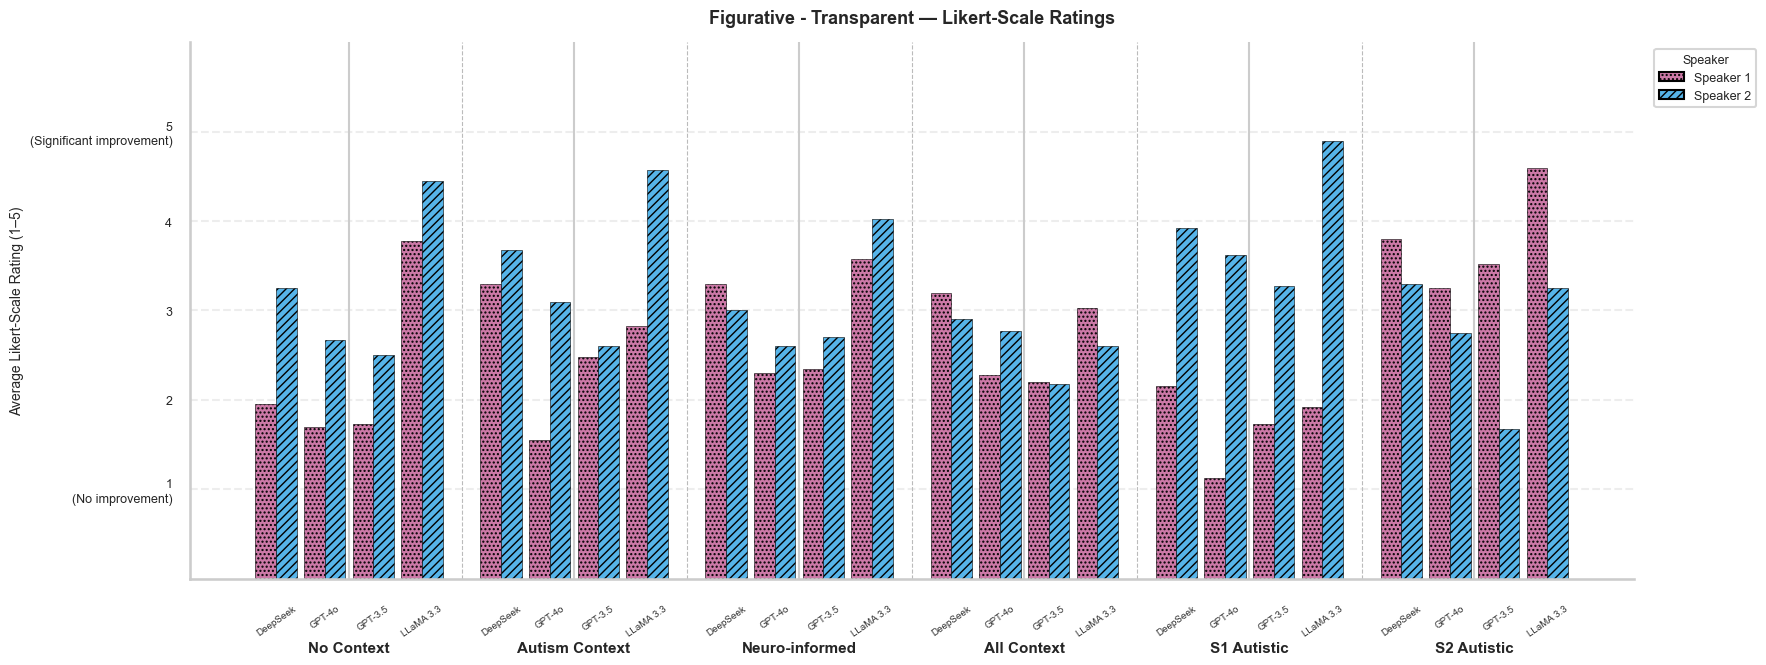

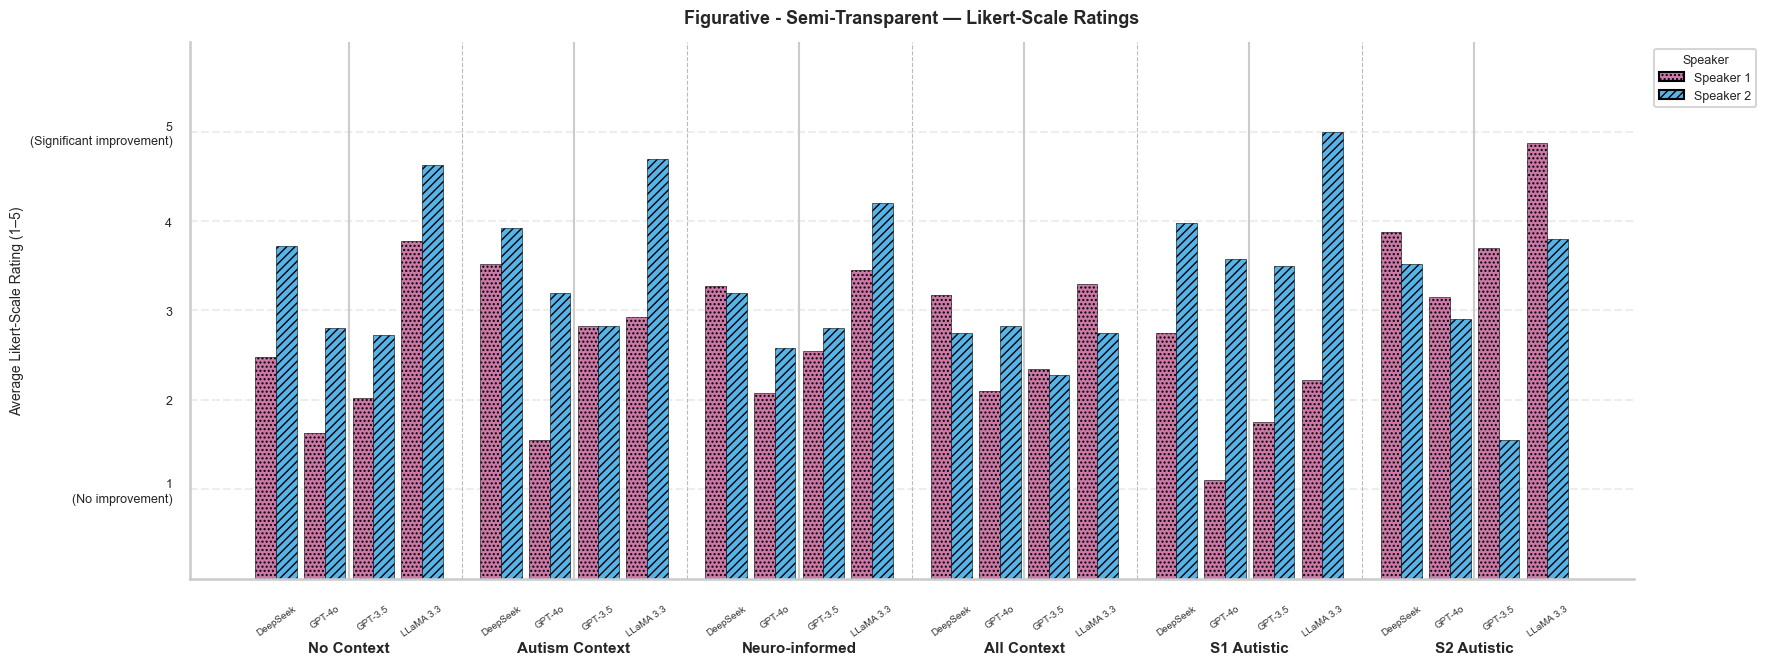

⏩ Missing: blunt_analysis\self.csv
⏩ Missing: blunt_analysis\non-self.csv
⏩ Missing: indirect_analysis\knowledge.csv
⏩ Missing: indirect_analysis\existential.csv
⏩ Missing: indirect_analysis\permission.csv
⏩ Missing: indirect_analysis\verification.csv


In [14]:
for folder, file, title in GRAPH_DEFINITIONS:
    p = Path(folder) / f"{file}.csv"
    if p.exists():
        plot_exact_ratings(p, title)
    else:
        print(f"⏩ Missing: {p}")